In [1]:
!pip install osmnx geopandas scikit-learn matplotlib contextily folium mapclassify hdbscan -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.3 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import folium
from folium.plugins import HeatMap

ox.settings.use_cache = True
ox.settings.log_console = False
print("OK")

OK


In [3]:
place_name = "Saint Petersburg, Russia"
tags = {"amenity": ["restaurant", "cafe", "fast_food"]}
pois_raw = ox.features_from_place(place_name, tags=tags)
print(f"Загружено: {len(pois_raw)}")

Загружено: 8065


In [4]:
pois = pois_raw.reset_index()
pois.set_geometry("geometry", inplace=True)
pois["geometry_point"] = pois.geometry.representative_point()
pois.set_geometry("geometry_point", inplace=True)
pois = pois.set_crs(pois_raw.crs, allow_override=True)
cols = ["name", "amenity", "geometry_point"]
pois = pois[[c for c in cols if c in pois.columns]].copy()
pois.rename_geometry("geometry", inplace=True)
print(f"Точек: {len(pois)}")

Точек: 8065


In [5]:
pois_m = pois.to_crs(epsg=32636)
pois_m["x"] = pois_m.geometry.x
pois_m["y"] = pois_m.geometry.y
X = pois_m[["x", "y"]].values
print("Координаты в метрах")

Координаты в метрах


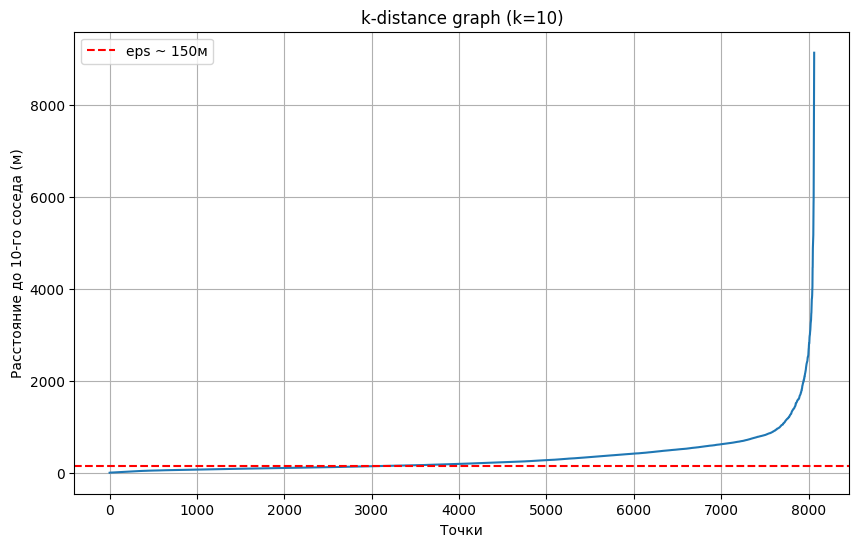

In [6]:
k = 10
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)
k_dist = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 6))
plt.plot(k_dist)
plt.axhline(y=150, color='r', linestyle='--', label='eps ~ 150м')
plt.title(f"k-distance graph (k={k})")
plt.xlabel("Точки")
plt.ylabel(f"Расстояние до {k}-го соседа (м)")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
eps = 150
min_samples = 10

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
pois_m["cluster_db"] = dbscan.fit_predict(X)

n_clust_db = pois_m.loc[pois_m["cluster_db"] != -1, "cluster_db"].nunique()
n_noise_db = (pois_m["cluster_db"] == -1).sum()

print(f"DBSCAN: eps={eps}м, min_samples={min_samples}")
print(f"Кластеров: {n_clust_db}, Шума: {n_noise_db}")

DBSCAN: eps=150м, min_samples=10
Кластеров: 102, Шума: 4174


In [9]:
hdb = HDBSCAN(min_cluster_size=15, min_samples=10)
pois_m["cluster_hdb"] = hdb.fit_predict(X)
pois_m["prob_hdb"] = hdb.probabilities_

n_clust_hdb = pois_m.loc[pois_m["cluster_hdb"] != -1, "cluster_hdb"].nunique()
n_noise_hdb = (pois_m["cluster_hdb"] == -1).sum()

print(f"HDBSCAN: min_cluster_size=15, min_samples=10")
print(f"Кластеров: {n_clust_hdb}, Шума: {n_noise_hdb}")

HDBSCAN: min_cluster_size=15, min_samples=10
Кластеров: 116, Шума: 2634


In [10]:
clusters_only = pois_m[pois_m["cluster_db"] != -1].copy()
summary = (
    clusters_only
    .groupby("cluster_db")
    .agg(
        count=("amenity", "count"),
        mean_x=("x", "mean"),
        mean_y=("y", "mean"),
        restaurants=("amenity", lambda s: (s == "restaurant").sum()),
        cafes=("amenity", lambda s: (s == "cafe").sum()),
        fast_food=("amenity", lambda s: (s == "fast_food").sum()),
    )
    .sort_values("count", ascending=False)
    .round(1)
)
print("Топ-10 кластеров DBSCAN:")
print(summary.head(10))

Топ-10 кластеров DBSCAN:
            count    mean_x     mean_y  restaurants  cafes  fast_food
cluster_db                                                           
0             931  352189.9  6646892.5          246    462        223
8             673  350287.7  6646811.8          182    359        132
19            168  348163.2  6648057.6           22     86         60
4              89  350012.1  6650756.4           15     48         26
24             80  349946.4  6644933.6            5     51         24
5              69  350039.5  6649715.1           10     42         17
21             69  348687.9  6650185.5           15     31         23
16             55  349405.5  6644083.7            5     11         39
7              49  347519.3  6643596.0            3     21         25
56             49  349414.5  6654998.6            1     13         35


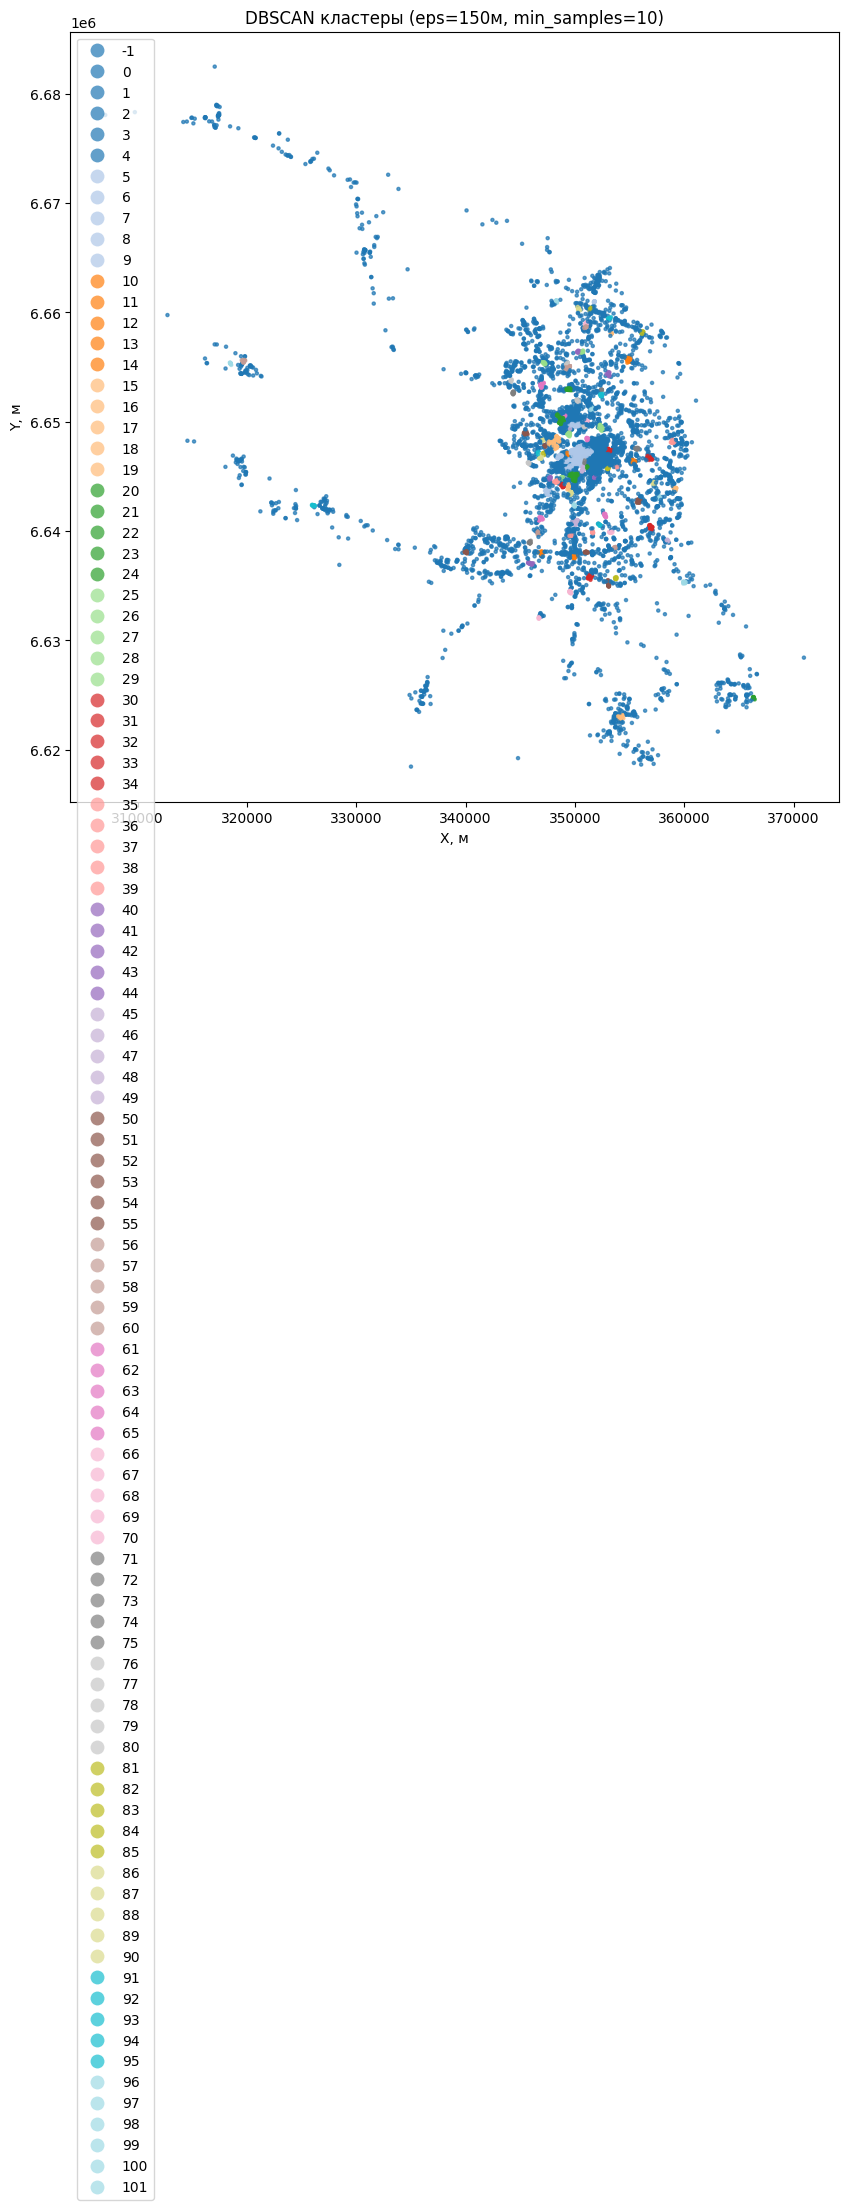

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))
pois_m.plot(ax=ax, column="cluster_db", categorical=True, markersize=5, legend=True, alpha=0.7, cmap="tab20")
ax.set_title(f"DBSCAN кластеры (eps={eps}м, min_samples={min_samples})")
ax.set_xlabel("X, м")
ax.set_ylabel("Y, м")
plt.show()

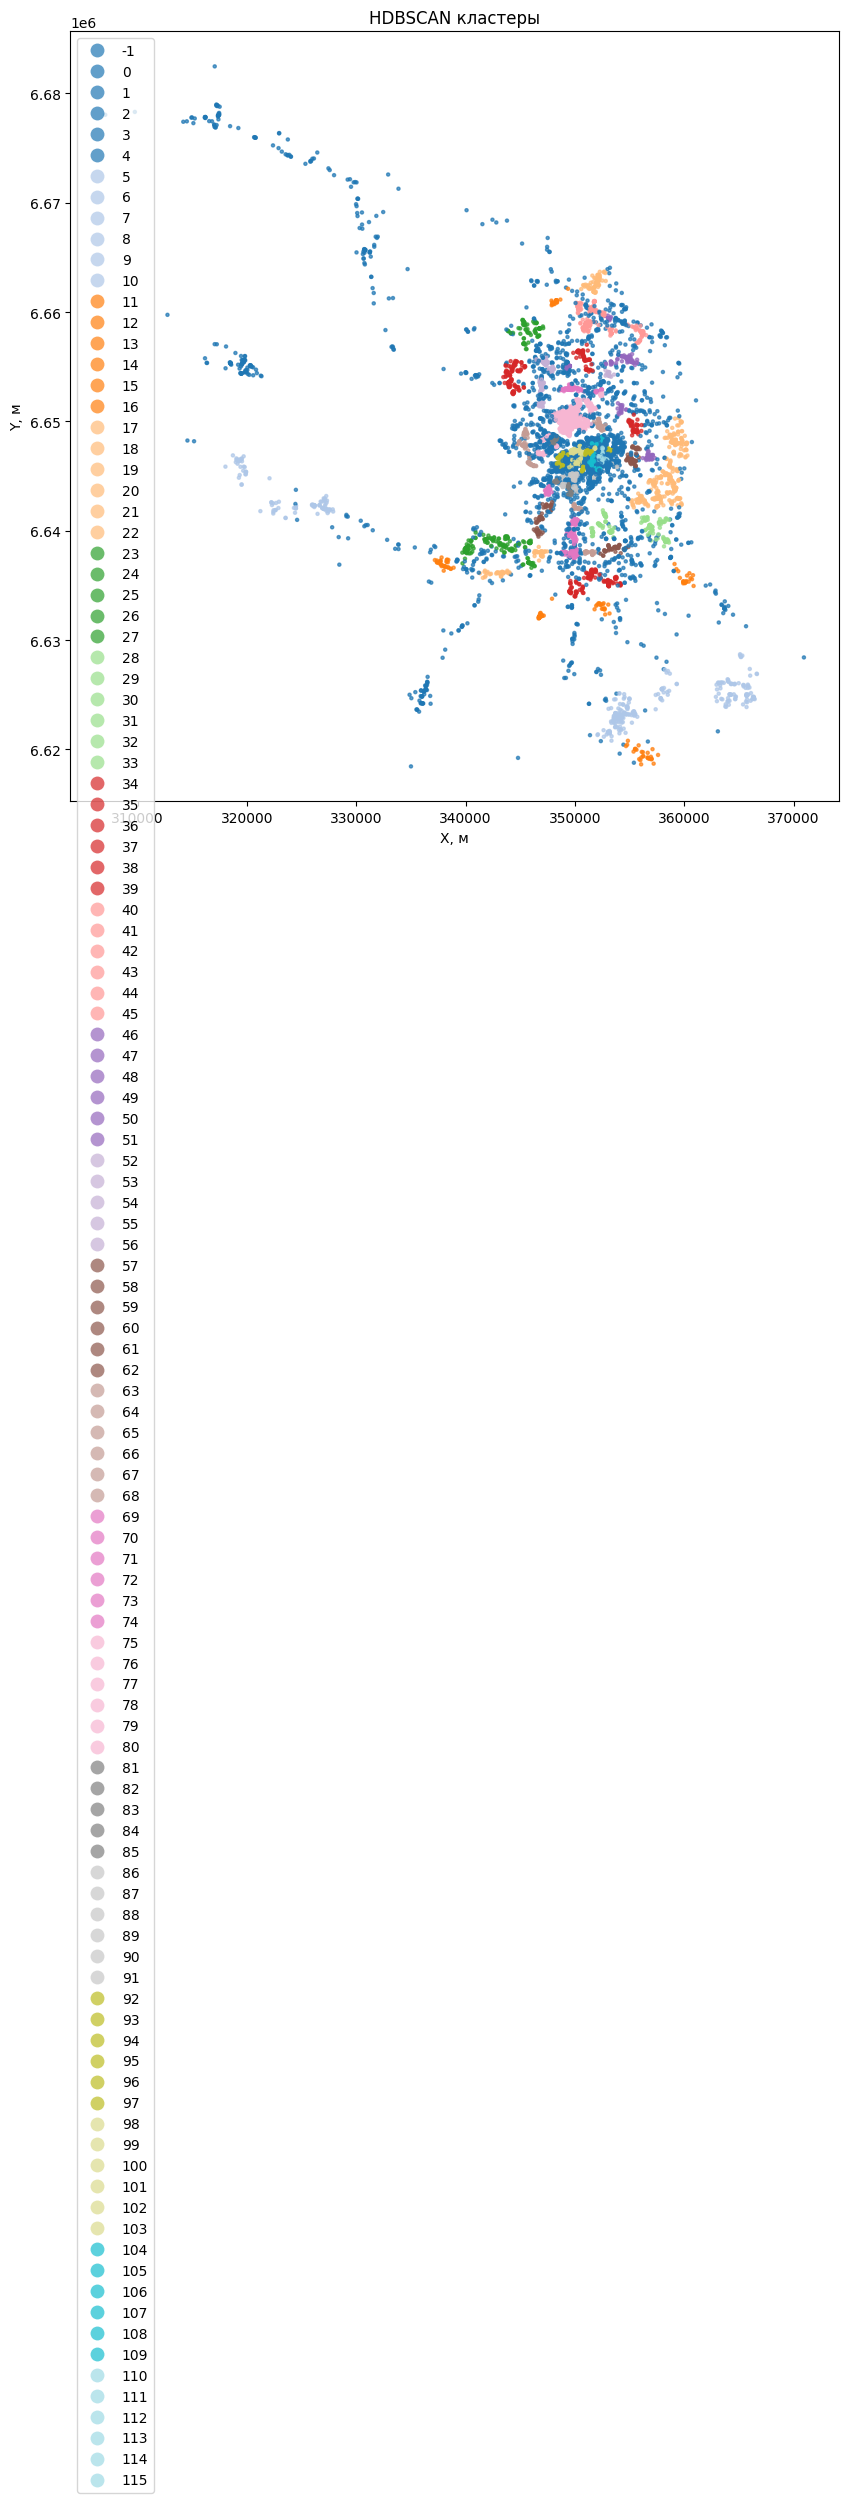

In [12]:
fig, ax = plt.subplots(figsize=(12, 10))
pois_m.plot(ax=ax, column="cluster_hdb", categorical=True, markersize=5, legend=True, alpha=0.7, cmap="tab20")
ax.set_title("HDBSCAN кластеры")
ax.set_xlabel("X, м")
ax.set_ylabel("Y, м")
plt.show()

In [13]:
comparison = pd.DataFrame({
    "Алгоритм": ["DBSCAN", "HDBSCAN"],
    "Кластеров": [n_clust_db, n_clust_hdb],
    "Шум": [n_noise_db, n_noise_hdb],
    "% шума": [round(n_noise_db/len(pois_m)*100, 1), round(n_noise_hdb/len(pois_m)*100, 1)]
})
print(comparison)

  Алгоритм  Кластеров   Шум  % шума
0   DBSCAN        102  4174    51.8
1  HDBSCAN        116  2634    32.7


In [14]:
mask_db = pois_m["cluster_db"] != -1
mask_hdb = pois_m["cluster_hdb"] != -1

if pois_m[mask_db]["cluster_db"].nunique() > 1:
    sil_db = silhouette_score(X[mask_db], pois_m[mask_db]["cluster_db"])
    print(f"Silhouette DBSCAN: {sil_db:.3f}")

if pois_m[mask_hdb]["cluster_hdb"].nunique() > 1:
    sil_hdb = silhouette_score(X[mask_hdb], pois_m[mask_hdb]["cluster_hdb"])
    print(f"Silhouette HDBSCAN: {sil_hdb:.3f}")

Silhouette DBSCAN: 0.339
Silhouette HDBSCAN: 0.577


In [15]:
def test_dbscan(eps_list, min_samples_list):
    results = []
    for eps in eps_list:
        for ms in min_samples_list:
            labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
            n_clust = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = np.sum(labels == -1)
            results.append({"eps": eps, "min_samples": ms, "clusters": n_clust, "noise": n_noise})
    return pd.DataFrame(results)

results = test_dbscan([100, 150, 200, 300, 500], [3, 5, 10, 20])
print(results)

    eps  min_samples  clusters  noise
0   100            3       527   2555
1   100            5       272   3715
2   100           10        96   5613
3   100           20        21   7353
4   150            3       444   1670
5   150            5       245   2550
6   150           10       102   4174
7   150           20        35   6094
8   200            3       373   1217
9   200            5       225   1884
10  200           10       103   3242
11  200           20        35   5091
12  300            3       289    642
13  300            5       195   1113
14  300           10        92   2265
15  300           20        44   3659
16  500            3       118    217
17  500            5        90    396
18  500           10        66    977
19  500           20        45   2107


In [16]:
def test_hdbscan(sizes, samples):
    results = []
    for sz in sizes:
        for sm in samples:
            labels = HDBSCAN(min_cluster_size=sz, min_samples=sm).fit_predict(X)
            n_clust = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = np.sum(labels == -1)
            results.append({"min_cluster_size": sz, "min_samples": sm, "clusters": n_clust, "noise": n_noise})
    return pd.DataFrame(results)

results_hdb = test_hdbscan([10, 15, 30, 50], [5, 10, 20])
print(results_hdb)

    min_cluster_size  min_samples  clusters  noise
0                 10            5       245   2222
1                 10           10       162   2718
2                 10           20        96   3265
3                 15            5       158   2271
4                 15           10       116   2634
5                 15           20        90   3290
6                 30            5        87   2439
7                 30           10        69   2870
8                 30           20        51   2568
9                 50            5        42   2310
10                50           10        32   1826
11                50           20         6    135


In [17]:
pois_wgs = pois_m.to_crs(epsg=4326)
center = [pois_wgs.geometry.y.mean(), pois_wgs.geometry.x.mean()]

m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

unique_clust = pois_wgs["cluster_hdb"].unique()
colors = {}
for i, c in enumerate(unique_clust):
    if c == -1:
        colors[c] = "gray"
    else:
        colors[c] = f"#{hash(c) % 0xFFFFFF:06x}"

for _, row in pois_wgs.sample(min(2000, len(pois_wgs))).iterrows():
    clust = row["cluster_hdb"]
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3 if clust != -1 else 1.5,
        color=colors.get(clust, "black"),
        fill=True,
        fill_opacity=0.6 if clust != -1 else 0.3,
        popup=f"{row.get('name', 'No name')}<br>Тип: {row.get('amenity', '?')}<br>Кластер: {clust}"
    ).add_to(m)

m.save("map.html")
m

In [18]:
heat_data = [[row.geometry.y, row.geometry.x] for _, row in pois_wgs.iterrows()]
m_heat = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")
HeatMap(heat_data, radius=15, blur=20, min_opacity=0.3).add_to(m_heat)
m_heat

In [19]:
pois_result = pois_m.to_crs(epsg=4326)
pois_result[["name", "amenity", "cluster_db", "cluster_hdb", "geometry"]].to_file("spb_food_clusters.geojson", driver="GeoJSON")
summary.to_csv("cluster_summary.csv", encoding="utf-8-sig")
print("Файлы сохранены")

Файлы сохранены
